# Policy fine-tune Phase 3 — diagnostics

Post-training analysis of a Phase 3 checkpoint vs the Phase 2 reference it was distilled from.

Set `CHECKPOINT_TO_ANALYZE` below to the Phase 3 checkpoint you want to look at. Set `PHASE2_REFERENCE_CKPT` to the Phase 2 final checkpoint used as the warm-start. Run cells top-to-bottom.

## 1. Setup

In [3]:
import json
import sys
from pathlib import Path

import chess
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch.amp.autocast_mode import autocast

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "training" / "train.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from training.train import ChessTransformer

# --- User-set: edit these to point at the checkpoints to compare ---
CHECKPOINT_TO_ANALYZE = PROJECT_ROOT / "models" / "guofish4" / "guofish4_25.6M_policy_final.pt"
PHASE2_REFERENCE_CKPT = PROJECT_ROOT / "models" / "guofish3" / "guofish3_25.6M_final_0.0691.pt"

POLICY_DATA_PATH    = PROJECT_ROOT / "data" / "processed" / "policy_singlepv_3M.pt"
VALUE_DATA_PATH     = PROJECT_ROOT / "data" / "processed" / "stockfish_eval_dataset_full.pt"

VAL_FRACTION = 0.05
BATCH_SIZE   = 640
SEED         = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {DEVICE}")
print(f"Phase 3 ckpt: {CHECKPOINT_TO_ANALYZE}")
print(f"Phase 2 ckpt: {PHASE2_REFERENCE_CKPT}")

Project root: c:\Users\Ethan Guo\Github\GuoFish
Device: cuda
Phase 3 ckpt: c:\Users\Ethan Guo\Github\GuoFish\models\guofish4\guofish4_25.6M_policy_final.pt
Phase 2 ckpt: c:\Users\Ethan Guo\Github\GuoFish\models\guofish3\guofish3_25.6M_final_0.0691.pt


## 2. Load both models

In [4]:
def load_model(path):
    assert Path(path).exists(), f"checkpoint not found: {path}"
    ck = torch.load(path, map_location="cpu", weights_only=True)
    m = ChessTransformer()
    m.load_state_dict(ck["model_state_dict"])
    return m.to(DEVICE).eval(), ck

phase2_model, phase2_ckpt = load_model(PHASE2_REFERENCE_CKPT)
phase3_model, phase3_ckpt = load_model(CHECKPOINT_TO_ANALYZE)

n_params = sum(p.numel() for p in phase3_model.parameters())
print(f"Phase 2 model params: {sum(p.numel() for p in phase2_model.parameters()):,}")
print(f"Phase 3 model params: {n_params:,}")

p3_cfg = phase3_ckpt.get("config", {})
print("\nPhase 3 config (relevant fields):")
for k in ("EPOCHS", "BATCH_SIZE", "ACCUM_STEPS", "POLICY_HEAD_LR", "BACKBONE_LR",
         "LABEL_SMOOTHING", "VALUE_ANCHOR_WEIGHT", "warm_started_from", "target_format"):
    if k in p3_cfg:
        print(f"  {k}: {p3_cfg[k]}")

c:\Users\Ethan Guo\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Phase 2 model params: 25,604,737
Phase 3 model params: 25,604,737

Phase 3 config (relevant fields):
  EPOCHS: 4
  BATCH_SIZE: 640
  ACCUM_STEPS: 3
  POLICY_HEAD_LR: 0.0001
  BACKBONE_LR: 1e-05
  LABEL_SMOOTHING: 0.1
  VALUE_ANCHOR_WEIGHT: 1.0
  warm_started_from: C:\Users\Ethan Guo\Github\GuoFish\models\guofish3\guofish3_25.6M_final_0.0691.pt
  target_format: indices


## 3. Policy diagnostic — Phase 2 vs Phase 3 on the Phase 3 val split

In [5]:
assert POLICY_DATA_PATH.exists(), f"policy dataset not found: {POLICY_DATA_PATH}"
pdata = torch.load(POLICY_DATA_PATH, weights_only=True)
tokens = pdata["tokens"]
targets = pdata.get("moves", pdata.get("targets"))
assert targets is not None, f"no 'moves' or 'targets' key in {list(pdata.keys())}"

target_fmt = "indices" if targets.ndim == 1 else "distribution"
print(f"Loaded {tokens.size(0):,} positions  (target format: {target_fmt})")

n_total = tokens.size(0)
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(n_total, generator=g)
n_val = int(n_total * VAL_FRACTION)
n_train = n_total - n_val
val_tokens  = tokens[perm[n_train:]]
val_targets = targets[perm[n_train:]]
if target_fmt == "indices":
    val_targets = val_targets.to(torch.long)
else:
    val_targets = val_targets.to(torch.float32)
print(f"Val: {n_val:,} positions")

@torch.no_grad()
def policy_metrics(model, tokens, targets, fmt, batch_size=BATCH_SIZE, label_smoothing=0.0):
    crit = torch.nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    model.eval()
    loss_sum = 0.0
    top1 = top5 = 0
    total = 0
    for i in range(0, tokens.size(0), batch_size):
        x = tokens[i:i+batch_size].to(DEVICE, dtype=torch.long, non_blocking=True)
        y = targets[i:i+batch_size]
        y_dev = y.to(DEVICE, dtype=torch.long if fmt == "indices" else torch.float32,
                     non_blocking=True)
        with autocast(device_type=DEVICE.type, dtype=torch.bfloat16):
            logits, _ = model(x)
        logits_f = logits.float()
        loss_sum += crit(logits_f, y_dev).item() * x.size(0)
        preds = logits_f.argmax(dim=-1)
        topk  = logits_f.topk(5, dim=-1).indices
        if fmt == "indices":
            top1 += (preds == y_dev).sum().item()
            top5 += (topk == y_dev.unsqueeze(-1)).any(dim=-1).sum().item()
        else:
            tgt_idx = y_dev.argmax(dim=-1)
            top1 += (preds == tgt_idx).sum().item()
            top5 += (topk == tgt_idx.unsqueeze(-1)).any(dim=-1).sum().item()
        total += x.size(0)
    return dict(loss=loss_sum/total, top1=top1/total, top5=top5/total)

print("Computing Phase 2 policy metrics...")
p2 = policy_metrics(phase2_model, val_tokens, val_targets, target_fmt)
print("Computing Phase 3 policy metrics...")
p3 = policy_metrics(phase3_model, val_tokens, val_targets, target_fmt)

print("\n=== Policy Head Comparison ===")
print(f"           Phase 2  ->  Phase 3   (delta)")
print(f"Top-1:     {p2['top1']*100:6.2f}%  ->  {p3['top1']*100:6.2f}%   (delta: {(p3['top1']-p2['top1'])*100:+6.2f}%)")
print(f"Top-5:     {p2['top5']*100:6.2f}%  ->  {p3['top5']*100:6.2f}%   (delta: {(p3['top5']-p2['top5'])*100:+6.2f}%)")
print()
print(f"Cross-entropy loss:")
print(f"  Phase 2:  {p2['loss']:.4f}")
print(f"  Phase 3:  {p3['loss']:.4f}")

Loaded 3,000,000 positions  (target format: indices)
Val: 150,000 positions
Computing Phase 2 policy metrics...
Computing Phase 3 policy metrics...

=== Policy Head Comparison ===
           Phase 2  ->  Phase 3   (delta)
Top-1:      43.46%  ->   46.81%   (delta:  +3.35%)
Top-5:      84.79%  ->   87.39%   (delta:  +2.59%)

Cross-entropy loss:
  Phase 2:  1.8351
  Phase 3:  1.7009


## 4. Policy distribution analysis

Entropy of the move distribution, top-1 probability mass, and Phase 2 vs Phase 3 agreement, on a 1000-position sample.

=== Distribution Sharpness ===
Mean entropy:        Phase 2 1.308 nats  ->  Phase 3 2.409 nats
Mean top-1 prob:     Phase 2 56.97%  ->  Phase 3 44.96%

=== Agreement ===
Phase 2 / Phase 3 top-1 agree: 76.20%  (238 disagreements)
Top-1 == Stockfish target: P2 44.00%   P3 46.20%
Among disagreements, matches Stockfish: P2 22.69%   P3 31.93%


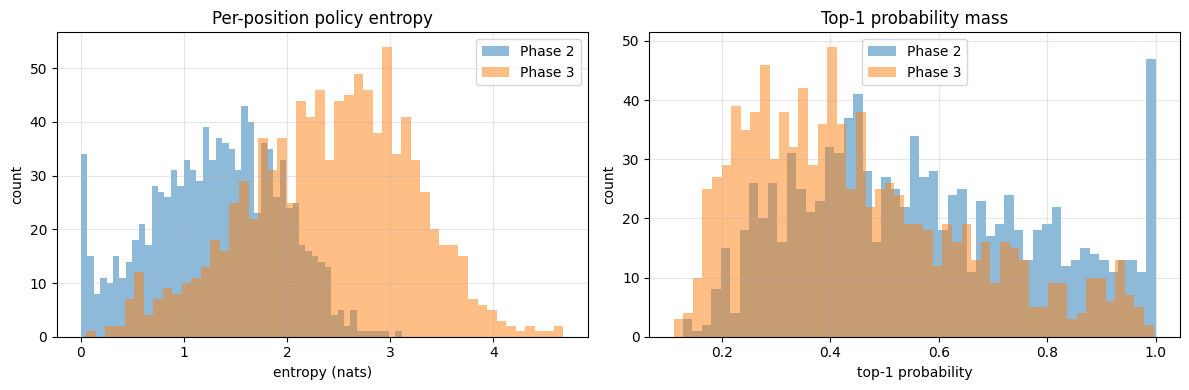

In [6]:
N_SAMPLE = 1000
sample_tokens  = val_tokens[:N_SAMPLE]
sample_targets = val_targets[:N_SAMPLE]

@torch.no_grad()
def collect_probs(model, tokens, batch_size=BATCH_SIZE):
    model.eval()
    chunks = []
    for i in range(0, tokens.size(0), batch_size):
        x = tokens[i:i+batch_size].to(DEVICE, dtype=torch.long, non_blocking=True)
        with autocast(device_type=DEVICE.type, dtype=torch.bfloat16):
            logits, _ = model(x)
        chunks.append(F.softmax(logits.float(), dim=-1).cpu())
    return torch.cat(chunks)

p2_probs = collect_probs(phase2_model, sample_tokens)
p3_probs = collect_probs(phase3_model, sample_tokens)

def entropy(probs):
    # Stable: ignore zero-probability terms
    safe = probs.clamp_min(1e-12)
    return -(probs * safe.log()).sum(dim=-1)

p2_ent = entropy(p2_probs)
p3_ent = entropy(p3_probs)
p2_top1_prob = p2_probs.max(dim=-1).values
p3_top1_prob = p3_probs.max(dim=-1).values
p2_top1 = p2_probs.argmax(dim=-1)
p3_top1 = p3_probs.argmax(dim=-1)

if target_fmt == "indices":
    sample_tgt_idx = sample_targets
else:
    sample_tgt_idx = sample_targets.argmax(dim=-1)

agreement = (p2_top1 == p3_top1).float().mean().item()
p2_match_target = (p2_top1 == sample_tgt_idx).float().mean().item()
p3_match_target = (p3_top1 == sample_tgt_idx).float().mean().item()
disagree_mask = p2_top1 != p3_top1
if disagree_mask.any():
    p2_match_when_disagree = (p2_top1[disagree_mask] == sample_tgt_idx[disagree_mask]).float().mean().item()
    p3_match_when_disagree = (p3_top1[disagree_mask] == sample_tgt_idx[disagree_mask]).float().mean().item()
else:
    p2_match_when_disagree = p3_match_when_disagree = float("nan")

print("=== Distribution Sharpness ===")
print(f"Mean entropy:        Phase 2 {p2_ent.mean().item():.3f} nats  ->  Phase 3 {p3_ent.mean().item():.3f} nats")
print(f"Mean top-1 prob:     Phase 2 {p2_top1_prob.mean().item()*100:.2f}%  ->  Phase 3 {p3_top1_prob.mean().item()*100:.2f}%")
print()
print("=== Agreement ===")
print(f"Phase 2 / Phase 3 top-1 agree: {agreement*100:.2f}%  ({int(disagree_mask.sum())} disagreements)")
print(f"Top-1 == Stockfish target: P2 {p2_match_target*100:.2f}%   P3 {p3_match_target*100:.2f}%")
print(f"Among disagreements, matches Stockfish: P2 {p2_match_when_disagree*100:.2f}%   P3 {p3_match_when_disagree*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(p2_ent.numpy(), bins=50, alpha=0.5, label="Phase 2", color="tab:blue")
axes[0].hist(p3_ent.numpy(), bins=50, alpha=0.5, label="Phase 3", color="tab:orange")
axes[0].set_xlabel("entropy (nats)"); axes[0].set_ylabel("count")
axes[0].set_title("Per-position policy entropy")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(p2_top1_prob.numpy(), bins=50, alpha=0.5, label="Phase 2", color="tab:blue")
axes[1].hist(p3_top1_prob.numpy(), bins=50, alpha=0.5, label="Phase 3", color="tab:orange")
axes[1].set_xlabel("top-1 probability"); axes[1].set_ylabel("count")
axes[1].set_title("Top-1 probability mass")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Value head drift check

Re-runs the Phase 2 value validation against Stockfish targets. If anchoring worked, Phase 3 numbers should match Phase 2's almost exactly.

Verdict: **PASS** if |delta Pearson r| < 0.03.

In [7]:
assert VALUE_DATA_PATH.exists(), f"value dataset not found: {VALUE_DATA_PATH}"
vdata = torch.load(VALUE_DATA_PATH, weights_only=True)
v_tokens, v_values = vdata["tokens"], vdata["values"]

n_v = v_tokens.size(0)
g_v = torch.Generator().manual_seed(SEED)
perm_v = torch.randperm(n_v, generator=g_v)
n_val_v = int(n_v * VAL_FRACTION)
val_v_tokens = v_tokens[perm_v[n_v - n_val_v:]]
val_v_values = v_values[perm_v[n_v - n_val_v:]]
print(f"Value val split: {val_v_tokens.size(0):,} positions")

@torch.no_grad()
def value_metrics(model, tokens, values, batch_size=BATCH_SIZE):
    model.eval()
    preds, tgts = [], []
    for i in range(0, tokens.size(0), batch_size):
        x = tokens[i:i+batch_size].to(DEVICE, dtype=torch.long, non_blocking=True)
        with autocast(device_type=DEVICE.type, dtype=torch.bfloat16):
            _, pv = model(x)
        preds.append(pv.float().cpu())
        tgts.append(values[i:i+batch_size])
    p = torch.cat(preds); t = torch.cat(tgts)
    mse = F.mse_loss(p, t).item()
    r = torch.corrcoef(torch.stack([p, t]))[0, 1].item()
    predict_mean_mse = ((t - t.mean()) ** 2).mean().item()
    improvement = (1.0 - mse / predict_mean_mse) * 100
    return dict(mse=mse, pearson_r=r, pred_std=p.std().item(),
                pred_mean=p.mean().item(), predict_mean_mse=predict_mean_mse,
                improvement_pct=improvement)

print("Phase 2 value metrics...")
vm2 = value_metrics(phase2_model, val_v_tokens, val_v_values)
print("Phase 3 value metrics...")
vm3 = value_metrics(phase3_model, val_v_tokens, val_v_values)

print("\n=== Value Head Drift Check ===")
print(f"Metric              Phase 2   Phase 3   Delta")
print(f"MSE:                {vm2['mse']:7.4f}   {vm3['mse']:7.4f}   {vm3['mse']-vm2['mse']:+7.4f}")
print(f"Pearson r:          {vm2['pearson_r']:7.4f}   {vm3['pearson_r']:7.4f}   {vm3['pearson_r']-vm2['pearson_r']:+7.4f}")
print(f"Prediction std:     {vm2['pred_std']:7.4f}   {vm3['pred_std']:7.4f}   {vm3['pred_std']-vm2['pred_std']:+7.4f}")
print(f"Improve vs mean:    {vm2['improvement_pct']:6.1f}%   {vm3['improvement_pct']:6.1f}%   {vm3['improvement_pct']-vm2['improvement_pct']:+6.1f}%")
delta_r = abs(vm3['pearson_r'] - vm2['pearson_r'])
verdict = "PASS" if delta_r < 0.03 else "FAIL"
print(f"\nVerdict: {verdict}  (|delta r| = {delta_r:.4f}, threshold 0.03)")

Value val split: 647,901 positions
Phase 2 value metrics...
Phase 3 value metrics...

=== Value Head Drift Check ===
Metric              Phase 2   Phase 3   Delta
MSE:                 0.0691    0.0748   +0.0057
Pearson r:           0.8822    0.8721   -0.0101
Prediction std:      0.5014    0.5028   +0.0014
Improve vs mean:      77.8%     76.0%     -1.8%

Verdict: PASS  (|delta r| = 0.0101, threshold 0.03)


## 6. Move-class analysis by game phase

Buckets val positions by piece count on the board into opening / middlegame / endgame and reports per-phase Top-1 accuracy. Reconstructs the board from the 68-token layout by reading the first 64 squares — token IDs match the piece encoding from `data/pgn_parallel.py`.

In [8]:
# Token IDs: 0 = empty square, 1-12 = pieces (per data/pgn_parallel._board_to_tokens).
# Phase bucketing uses raw piece count, which only requires distinguishing empty (0) from non-empty.
EMPTY_TOKEN = 0

def piece_counts(tokens_batch):
    sq = tokens_batch[:, :64].to(torch.int64)
    return (sq != EMPTY_TOKEN).sum(dim=-1)

@torch.no_grad()
def per_phase_top1(model, tokens, targets, fmt, batch_size=BATCH_SIZE):
    model.eval()
    buckets = {"opening": [0, 0], "middlegame": [0, 0], "endgame": [0, 0]}
    for i in range(0, tokens.size(0), batch_size):
        x = tokens[i:i+batch_size].to(DEVICE, dtype=torch.long, non_blocking=True)
        y = targets[i:i+batch_size]
        y_idx = y.to(DEVICE, dtype=torch.long) if fmt == "indices" else y.to(DEVICE).argmax(dim=-1)
        with autocast(device_type=DEVICE.type, dtype=torch.bfloat16):
            logits, _ = model(x)
        preds = logits.float().argmax(dim=-1)
        correct = (preds == y_idx).cpu()
        pc = piece_counts(tokens[i:i+batch_size])
        opening_mask    = pc >= 28
        endgame_mask    = pc <= 12
        middlegame_mask = (~opening_mask) & (~endgame_mask)
        for name, mask in (("opening", opening_mask),
                           ("middlegame", middlegame_mask),
                           ("endgame", endgame_mask)):
            n = int(mask.sum())
            if n:
                buckets[name][0] += int(correct[mask].sum())
                buckets[name][1] += n
    return {k: (c / max(1, n), n) for k, (c, n) in buckets.items()}

print("Per-phase Phase 2...")
phase2_buckets = per_phase_top1(phase2_model, val_tokens, val_targets, target_fmt)
print("Per-phase Phase 3...")
phase3_buckets = per_phase_top1(phase3_model, val_tokens, val_targets, target_fmt)

print("\n=== Top-1 by Game Phase ===")
print(f"{'Phase':<12}  {'N':>8}   {'Phase 2':>9}   {'Phase 3':>9}   {'Delta':>8}")
for k in ("opening", "middlegame", "endgame"):
    a2, n2 = phase2_buckets[k]
    a3, _ = phase3_buckets[k]
    print(f"{k:<12}  {n2:>8,}   {a2*100:8.2f}%   {a3*100:8.2f}%   {(a3-a2)*100:+7.2f}%")

Per-phase Phase 2...
Per-phase Phase 3...

=== Top-1 by Game Phase ===
Phase                N     Phase 2     Phase 3      Delta
opening         44,762      41.68%      46.59%     +4.91%
middlegame      67,035      43.44%      45.40%     +1.97%
endgame         38,203      45.57%      49.54%     +3.97%


## 7. Training trajectory from log

Reads the most recent `phase3_ckpt_log_*.json` and plots checkpoint-level metrics. Edit `LOG_JSON` below to pick a specific run.

Loading: phase3_ckpt_log_20260531_033939.json


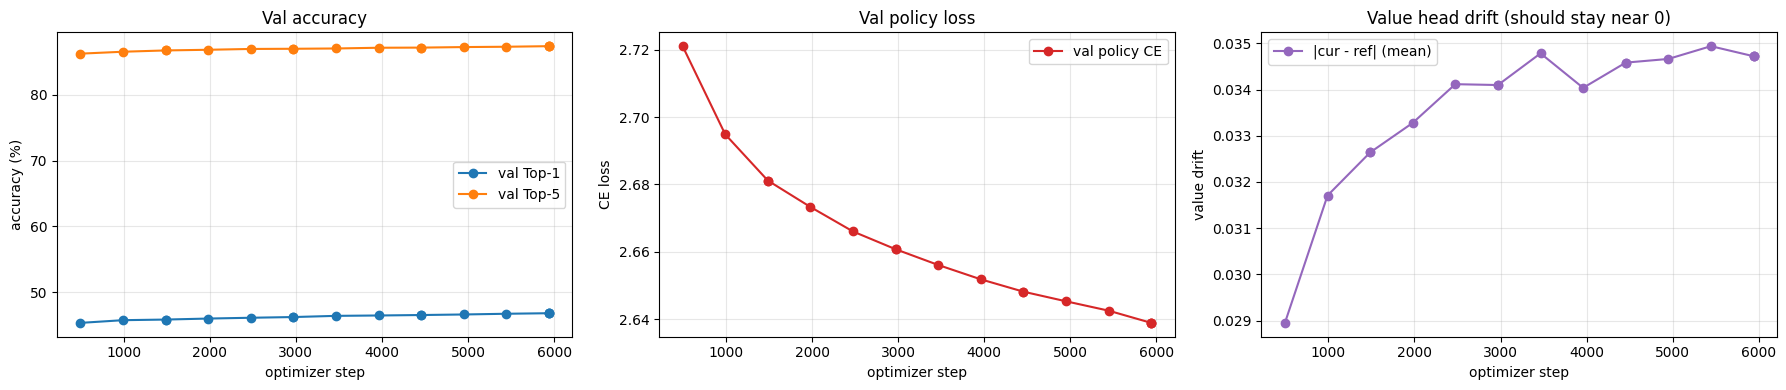


Value correlation per checkpoint (should stay near 1.0):
  ckpt=1               step=   495  corr=0.9962  drift=0.0290
  ckpt=2               step=   990  corr=0.9954  drift=0.0317
  ckpt=3               step=  1485  corr=0.9951  drift=0.0326
  ckpt=epoch1_end      step=  1485  corr=0.9951  drift=0.0326
  ckpt=4               step=  1980  corr=0.9950  drift=0.0333
  ckpt=5               step=  2475  corr=0.9949  drift=0.0341
  ckpt=6               step=  2970  corr=0.9948  drift=0.0341
  ckpt=epoch2_end      step=  2970  corr=0.9948  drift=0.0341
  ckpt=7               step=  3465  corr=0.9946  drift=0.0348
  ckpt=8               step=  3960  corr=0.9948  drift=0.0340
  ckpt=9               step=  4455  corr=0.9946  drift=0.0346
  ckpt=epoch3_end      step=  4455  corr=0.9946  drift=0.0346
  ckpt=10              step=  4950  corr=0.9946  drift=0.0347
  ckpt=11              step=  5445  corr=0.9945  drift=0.0349
  ckpt=12              step=  5940  corr=0.9945  drift=0.0347
  ckpt=epoch

In [9]:
LOGS_DIR = PROJECT_ROOT / "training" / "logs"
candidates = sorted(LOGS_DIR.glob("phase3_ckpt_log_*.json"))
if not candidates:
    print("No phase3_ckpt_log_*.json files found — skipping plot.")
else:
    LOG_JSON = candidates[-1]
    print(f"Loading: {LOG_JSON.name}")
    with open(LOG_JSON) as f:
        ckpt_log = json.load(f)

    steps      = [r["step"]                  for r in ckpt_log]
    pol_loss   = [r["val_policy_loss"]       for r in ckpt_log]
    top1       = [r["val_top1"] * 100        for r in ckpt_log]
    top5       = [r["val_top5"] * 100        for r in ckpt_log]
    drift      = [r["val_value_drift"]       for r in ckpt_log]
    corr       = [r["val_value_correlation"] for r in ckpt_log]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(steps, top1, marker="o", label="val Top-1")
    axes[0].plot(steps, top5, marker="o", label="val Top-5", color="tab:orange")
    axes[0].set_xlabel("optimizer step"); axes[0].set_ylabel("accuracy (%)")
    axes[0].set_title("Val accuracy"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(steps, pol_loss, marker="o", color="tab:red", label="val policy CE")
    axes[1].set_xlabel("optimizer step"); axes[1].set_ylabel("CE loss")
    axes[1].set_title("Val policy loss"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    axes[2].plot(steps, drift, marker="o", color="tab:purple", label="|cur - ref| (mean)")
    axes[2].set_xlabel("optimizer step"); axes[2].set_ylabel("value drift")
    axes[2].set_title("Value head drift (should stay near 0)")
    axes[2].legend(); axes[2].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    print("\nValue correlation per checkpoint (should stay near 1.0):")
    for r in ckpt_log:
        print(f"  ckpt={str(r['ckpt']):<14}  step={r['step']:>6}  corr={r['val_value_correlation']:.4f}  drift={r['val_value_drift']:.4f}")